In [1]:
import pandas as pd
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from se_coast_strandings import (
    make_dt_col,
    make_cyclic,
    make_season_col,
    make_cyclic_season,
)

In [2]:
data_dir = Path("../data/raw")

In [3]:
df = pd.read_excel(data_dir / "UNC-DataRequest-01302026.xlsx", sheet_name="2015-2024")

In [4]:
print(df.columns)

Index(['National Database Number', 'Confidence Code', 'Common Name', 'Genus',
       'Species', 'County', 'State', 'Latitude', 'Latitude Units',
       'Latitude Actual/Estimate', 'Longitude', 'Longitude Units',
       'Longitude Actual/Estimate', 'How lat/long determined',
       'Year of Observation', 'Month of Observation', 'Day of Observation',
       'Observation Status', 'Examined', 'Date of Examination',
       'Condition at Examination', 'Left at Site', 'Immediate Release at Site',
       'Relocated Flag', 'Euthanized at Site Flag', 'Died at Site Flag',
       'Transferred to Rehabilitation', 'Died During Transport Flag',
       'Euthanized During Transport', 'Sick Flag', 'Injured Flag',
       'Out of Habitat Flag', 'Deemed Healthy/Releasable Flag',
       'Abandoned/Orphaned Flag', 'Inaccesible Flag',
       'Location Hazardous to Animal', 'Location Hazardous Public',
       'Unknown/CBD Flag', 'Condition Comments', 'Sex', 'Age Class',
       '2007 Whole Carcass', '2007 Parti

In [5]:
df["Latitude Actual/Estimate"].value_counts(dropna=False)

Latitude Actual/Estimate
actual      2011
estimate     530
NaN            9
Name: count, dtype: int64

In [6]:
same = df["Latitude Actual/Estimate"] == df["Longitude Actual/Estimate"]
df = df[same]

In [7]:
df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")
df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")
df = df[~df["Longitude"].isna() & ~df["Latitude"].isna()]

In [8]:
df["is_actual_coords"] = df["Latitude Actual/Estimate"] == "actual"

In [9]:
df["is_actual_coords"].value_counts(dropna=False)

is_actual_coords
True     1990
False     528
Name: count, dtype: int64

In [10]:
df[["Day of Observation", "Month of Observation", "Year of Observation"]].head(5)

,Day of Observation,Month of Observation,Year of Observation
0,20,JUL,2024
1,27,MAY,2016
2,28,MAY,2016
3,19,JUN,2021
4,29,JUN,2021


In [11]:
df["mms_observation_dt"] = make_dt_col(
    df["Day of Observation"], df["Month of Observation"], df["Year of Observation"]
)

In [12]:
df["dayofweek_sin"], df["dayofweek_cos"] = make_cyclic(
    df["mms_observation_dt"].dt.dayofweek, 7, name="dayofweek"
)
df["month_sin"], df["month_cos"] = make_cyclic(
    df["mms_observation_dt"].dt.month, 12, name="month"
)

In [13]:
df["season"] = make_season_col(df["mms_observation_dt"])
df["season_sin"], df["season_cos"] = make_cyclic_season(
    df["mms_observation_dt"], name="season"
)

In [14]:
df["dayofyear_sin"], df["dayofyear_cos"] = make_cyclic(
    df["mms_observation_dt"].dt.dayofyear, 365, name="dayofyear"
)

In [15]:
cyclic_features = df[
    [c for c in df.columns if c.endswith("_sin") or c.endswith("_cos")]
]
cyclic_features

,dayofweek_sin,dayofweek_cos,month_sin,month_cos,season_sin,season_cos,dayofyear_sin,dayofyear_cos
0,-0.974928,-0.222521,-5.000000e-01,-0.866025,1.0,6.123234e-17,-0.329408,-0.944188
1,-0.433884,-0.900969,5.000000e-01,-0.866025,0.0,1.000000e+00,0.559589,-0.828770
2,-0.974928,-0.222521,5.000000e-01,-0.866025,0.0,1.000000e+00,0.545240,-0.838280
3,-0.974928,-0.222521,1.224647e-16,-1.000000,0.0,1.000000e+00,0.213521,-0.976938
4,0.781832,0.623490,1.224647e-16,-1.000000,1.0,6.123234e-17,0.043022,-0.999074
...,...,...,...,...,...,...,...,...
2545,-0.781832,0.623490,-2.449294e-16,1.000000,-1.0,-1.836970e-16,-0.137279,0.990532
2546,0.781832,0.623490,8.660254e-01,-0.500000,0.0,1.000000e+00,0.991114,-0.133015
2547,0.781832,0.623490,8.660254e-01,0.500000,-1.0,-1.836970e-16,0.711657,0.702527
2548,0.433884,-0.900969,-5.000000e-01,-0.866025,1.0,6.123234e-17,-0.345612,-0.938377


## Coordinate Reference System (CRS) Note

All strandings operations in this notebook use **EPSG:4326** (WGS 84, decimal degrees).
This is the native CRS of the NOAA strandings coordinates. The `assign_region()` function
used in the modeling pipeline also operates on raw decimal-degree latitudes — no reprojection
is needed.

Note: Notebook `01_c_plankton_data_clean` uses **EPSG:5070** (NAD83 / Conus Albers) for
spatial buffering operations only. That CRS choice does not affect the strandings pipeline.

In [16]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326",
)

In [17]:
states = gpd.read_file("../data/reference/cb_2018_us_state_5m.shp").set_crs("EPSG:4326")
states.shape, states.crs

((56, 10),
 <Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich)

In [18]:
se_coast_states = states[
    states["NAME"].isin(
        [
            "Virginia",
            "North Carolina",
            "South Carolina",
        ]
    )
]
se_coast_states

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
15,37,01027616,0400000US37,37,NC,North Carolina,00,125923656064,13466071395,"MULTIPOLYGON (((-75.72681 35.93584, -75.71827 ..."
33,51,01779803,0400000US51,51,VA,Virginia,00,102257717110,8528531774,"MULTIPOLYGON (((-75.99966 37.8482, -75.99686 3..."
43,45,01779799,0400000US45,45,SC,South Carolina,00,77864918488,5075218778,"POLYGON ((-83.35324 34.72865, -83.34883 34.737..."


In [19]:
gdf["_t"] = mdates.date2num(gdf["mms_observation_dt"])

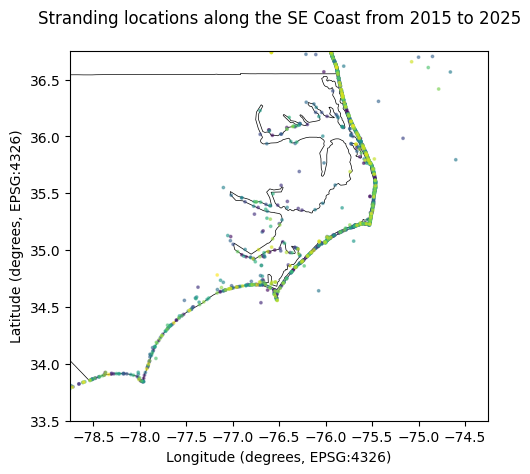

In [20]:
out_path = Path("../figures/jh_strandings_dataset_nc_map.png")

fig, ax = plt.subplots()

se_coast_states.loc[se_coast_states["STUSPS"] == "NC"].plot(
    ax=ax,
    edgecolor="black",
    facecolor="none",
    linewidth=0.5,
    figsize=(12, 12),
)

gdf.plot(
    ax=ax,
    column="_t",
    markersize=3,
    cmap="viridis",
    alpha=0.5,
)

ax.set_xlim(-78.75, -74.25)
ax.set_ylim(33.5, 36.75)
ax.set_title("Stranding locations along the SE Coast from 2015 to 2025", pad=20)
ax.set_xlabel("Longitude (degrees, EPSG:4326)")
ax.set_ylabel("Latitude (degrees, EPSG:4326)")

plt.savefig(out_path)
plt.show()

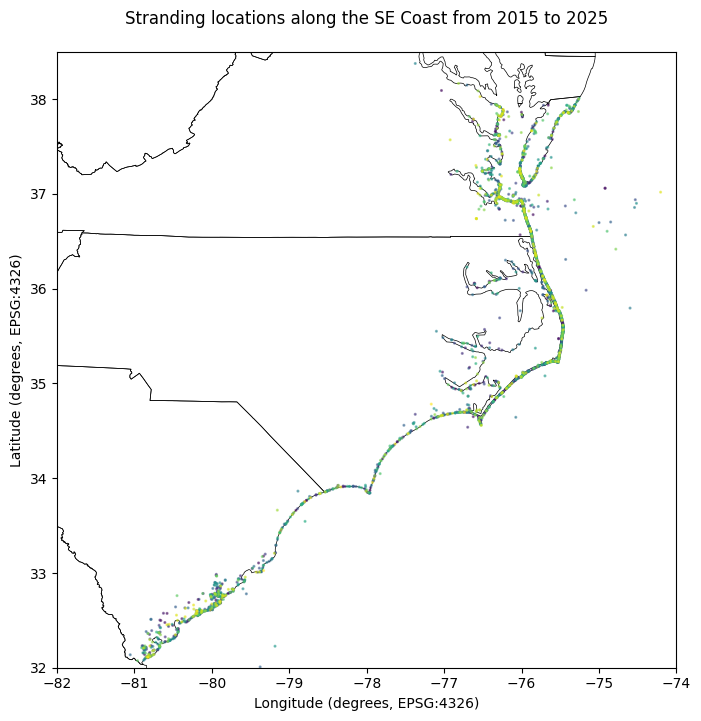

In [21]:
out_path = Path("../figures/jh_strandings_dataset_map.png")


ax = states.plot(edgecolor="black", facecolor="none", linewidth=0.5, figsize=(8, 8))
gdf.plot(ax=ax, column="_t", markersize=1.5, cmap="viridis", alpha=0.5)

ax.set_xlim(-82, -74)
ax.set_ylim(32, 38.5)
ax.set_title("Stranding locations along the SE Coast from 2015 to 2025", pad=20)
ax.set_xlabel("Longitude (degrees, EPSG:4326)")
ax.set_ylabel("Latitude (degrees, EPSG:4326)")
plt.savefig(out_path, dpi=300)
